<a href="https://colab.research.google.com/github/mvgolubev99/kaggle-chemical-structure-and-logp/blob/dev/interaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cells for google colab

## Clone repository

In [ ]:
# clone repo
!git clone https://github.com/mvgolubev99/kaggle-chemical-structure-and-logp.git

Cloning into 'kaggle-chemical-structure-and-logp'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 150 (delta 85), reused 84 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 1.89 MiB | 5.83 MiB/s, done.
Resolving deltas: 100% (85/85), done.


In [ ]:
# cd to project directory
!pwd
%cd /content/kaggle-chemical-structure-and-logp/
!pwd
!ls

/content
/content/kaggle-chemical-structure-and-logp
/content/kaggle-chemical-structure-and-logp
README.md


In [ ]:
# checkout to branch if neccesary
!git checkout dev
!ls

Branch 'dev' set up to track remote branch 'dev' from 'origin'.
Switched to a new branch 'dev'
cfg.md	 experiments.py       main.py		requirements.txt
configs  experiment_utils.py  models.py		utils.py
data	 fingerprints.py      preprocessing.py
eda.py	 interaction.ipynb    README.md


## Install packages

In [ ]:
# install packages
!pip install rdkit optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 22.1 MB/s eta 0:00:00


# Interaction

## Download data and convert to fingerprints

In [ ]:
# download data
!mkdir -p ./data; curl -L -o ./data/archive_logp.zip https://www.kaggle.com/api/v1/datasets/download/matthewmasters/chemical-structure-and-logp; unzip ./data/archive_logp.zip -d ./data/; rm ./data/archive_logp.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 81468  100 81468    0     0   187k      0 --:--:-- --:--:-- --:--:--  187k
Archive:  ./data/archive_logp.zip
  inflating: ./data/logP_dataset.csv  


In [ ]:
# generate fingerprints
!python fingerprints.py

Converting data from smiles to all fingerprints...

saving fingerprints to folder: 'data'

[1/7]
fp_name=MorganFingerprint_2048 
fingerprints saved as 'data/MorganFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[2/7]
fp_name=FeaturesMorganFingerprint_2048 
fingerprints saved as 'data/FeaturesMorganFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[3/7]
fp_name=MACCSKeysFingerprint_167 
fingerprints saved as 'data/MACCSKeysFingerprint_167_X_data.npy'
fps.shape=(14610, 167)
[4/7]
fp_name=RDKitFingerprint_2048 
fingerprints saved as 'data/RDKitFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[5/7]
fp_name=AtomPairFingerprint_2048 
fingerprints saved as 'data/AtomPairFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[6/7]
fp_name=TopologicalTorsionFingerprint_2048 
fingerprints saved as 'data/TopologicalTorsionFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[7/7]
fp_name=AvalonFingerprint_1024 
fingerprints saved as 'data/AvalonFingerprint_1024_X_data.npy'
fps.shape=(14

## Imports, seed

In [ ]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from experiments import ExperimentOptunaSearch, ExperimentGridSearch, run_hp_search_experiment

In [ ]:
# FIX SEED!
from utils import set_seed
set_seed(42)

## Test TPE search

[I 2025-11-24 12:15:14,615] A new study created in memory with name: new_test_tpe
[I 2025-11-24 12:15:15,125] Trial 0 finished with value: 1.3055349452980276 and parameters: {'data_representation': 'fp_2', 'model': 'sklearn.dummy.DummyRegressor', 'sklearn.dummy.DummyRegressor__strategy': 'mean'}. Best is trial 0 with value: 1.3055349452980276.
[I 2025-11-24 12:15:17,923] Trial 1 finished with value: 0.9378363662096817 and parameters: {'data_representation': 'fp_2', 'model': 'sklearn.linear_model.Lasso', 'sklearn.linear_model.Lasso__alpha': 0.020584494295802447, 'sklearn.linear_model.Lasso__random_state': 42}. Best is trial 1 with value: 0.9378363662096817.
[I 2025-11-24 12:15:18,558] Trial 2 finished with value: 1.305422351665667 and parameters: {'data_representation': 'fp_1', 'model': 'sklearn.dummy.DummyRegressor', 'sklearn.dummy.DummyRegressor__strategy': 'median'}. Best is trial 1 with value: 0.9378363662096817.


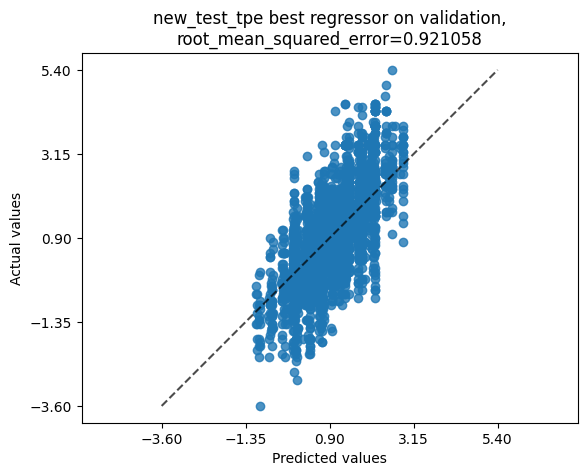


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.9378363662096817
data_representation:
  fp_name_or_path: FeaturesMorganFingerprint_2048
from_experiment: new_test_tpe
model: sklearn.linear_model.Lasso
model_kwargs:
  alpha: 0.020584494295802447
  random_state: 42
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.8939374919881032
  - 0.9452486359421809
  score_mean: 0.9204126696578921



In [ ]:
exp = ExperimentOptunaSearchCV("./configs/test_tpe.yaml").run()

## Test Grid search

/usr/local/lib/python3.12/dist-packages/optuna/samplers/_grid.py:232: UserWarning: params contains a value with the type of <class 'dict'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)
[I 2025-11-24 12:15:19,971] A new study created in memory with name: new_test_grid
[I 2025-11-24 12:15:21,860] Trial 0 finished with value: 1.3055349452980276 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'FeaturesMorganFingerprint_2048'}, 'model': 'sklearn.linear_model.Lasso', 'model_kwargs': {'random_state': 41}}}. Best is trial 0 with value: 1.3055349452980276.
[I 2025-11-24 12:15:23,709] Trial 1 finished with value: 1.3055349452980276 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'FeaturesMorganFingerprint_2048'}, 'model': 'sklearn.linear_model.Lasso', 'model_kwargs': {'random_state': 42}}}. Best is trial 0 with value: 1.3055349452980276.
[

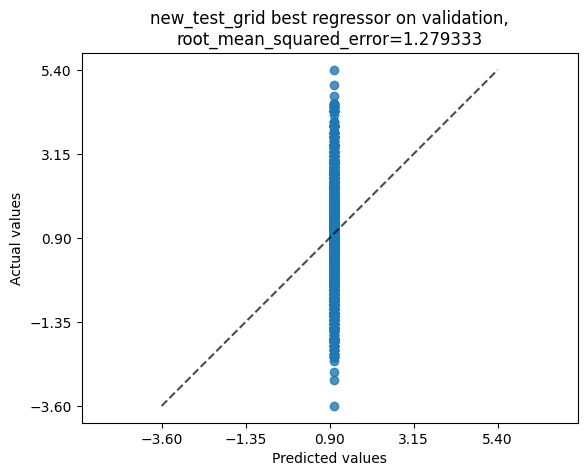


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 1.3055349452980276
data_representation:
  fp_name_or_path: FeaturesMorganFingerprint_2048
from_experiment: new_test_grid
model: sklearn.linear_model.Lasso
model_kwargs:
  random_state: 41
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 1.2449657689484226
  - 1.3125620077648492
  score_mean: 1.2788324039349168



In [ ]:
exp = ExperimentGridSearchCV("./configs/test_grid.yaml").run()

## Grid search, fingerprints, default models

[I 2025-11-22 20:10:34,369] A new study created in memory with name: grid_search_all_fp_default_models
[I 2025-11-22 20:10:34,628] Trial 0 finished with value: 1.305422351665667 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'TopologicalTorsionFingerprint_2048'}, 'model': 'sklearn.dummy.DummyRegressor', 'model_kwargs': {'strategy': 'median'}}}. Best is trial 0 with value: 1.305422351665667.
[I 2025-11-22 20:10:34,781] Trial 1 finished with value: 1.305422351665667 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'sklearn.dummy.DummyRegressor', 'model_kwargs': {'strategy': 'median'}}}. Best is trial 0 with value: 1.305422351665667.
[I 2025-11-22 20:10:55,622] Trial 2 finished with value: 0.4618754186586088 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AtomPairFingerprint_2048'}, 'model': 'xgboost.XGBRegressor', 'model_kwargs': {'random_state': 42, 'verbosity': 0}}}. Best is trial 

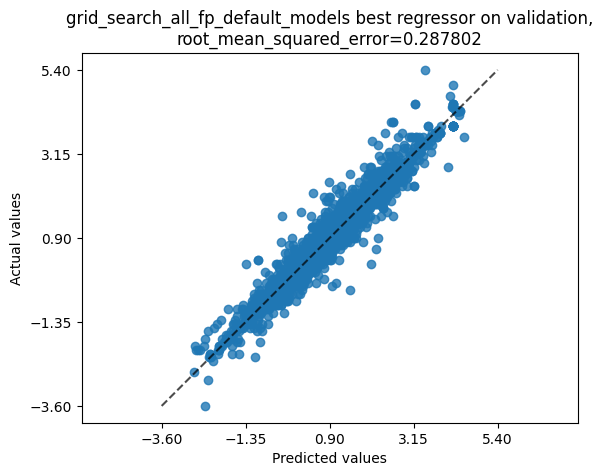


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.2998434249367179
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: grid_search_all_fp_default_models
model: sklearn.neural_network.MLPRegressor
model_kwargs:
  random_state: 42
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.2711614427856121
  - 0.30352161110715853
  score_mean: 0.28703889130671245



In [ ]:
with warnings.catch_warnings():
    # lgbm creates column names for features
    # even though no arrays or dataframes are passed as arguments to .fit() method
    warnings.filterwarnings("ignore", category=UserWarning)

    exp = ExperimentGridSearchCV("./configs/grid_search_all_fp_default_models.yaml").run()

In [ ]:
import ast

df = pd.read_csv("./results/grid_search_all_fp_default_models/grid_search_all_fp_default_models_all_trials_results.csv")
df["fp_name"] = df["params"].apply(
    lambda params: ast.literal_eval(params).get('data_representation').get('fp_name_or_path')
)
df["model"] = df["params"].apply(
    lambda params: ast.literal_eval(params).get('model').rsplit(".", 1)[1]
)
df.drop("params", axis=1, inplace=True)
print(df)

       value                             fp_name           model
0   1.305422  TopologicalTorsionFingerprint_2048  DummyRegressor
1   1.305422              AvalonFingerprint_1024  DummyRegressor
2   0.461875            AtomPairFingerprint_2048    XGBRegressor
3   0.799528              MorganFingerprint_2048   LGBMRegressor
4   0.799528      FeaturesMorganFingerprint_2048   LGBMRegressor
5   1.305535            AtomPairFingerprint_2048           Lasso
6   0.466621            AtomPairFingerprint_2048   LGBMRegressor
7   0.832717      FeaturesMorganFingerprint_2048    MLPRegressor
8   1.305535              AvalonFingerprint_1024           Lasso
9   1.305535  TopologicalTorsionFingerprint_2048           Lasso
10  0.351693            AtomPairFingerprint_2048    MLPRegressor
11  0.509472               RDKitFingerprint_2048           Ridge
12  0.346166              AvalonFingerprint_1024    XGBRegressor
13  0.810611              MorganFingerprint_2048           Ridge
14  0.299843             

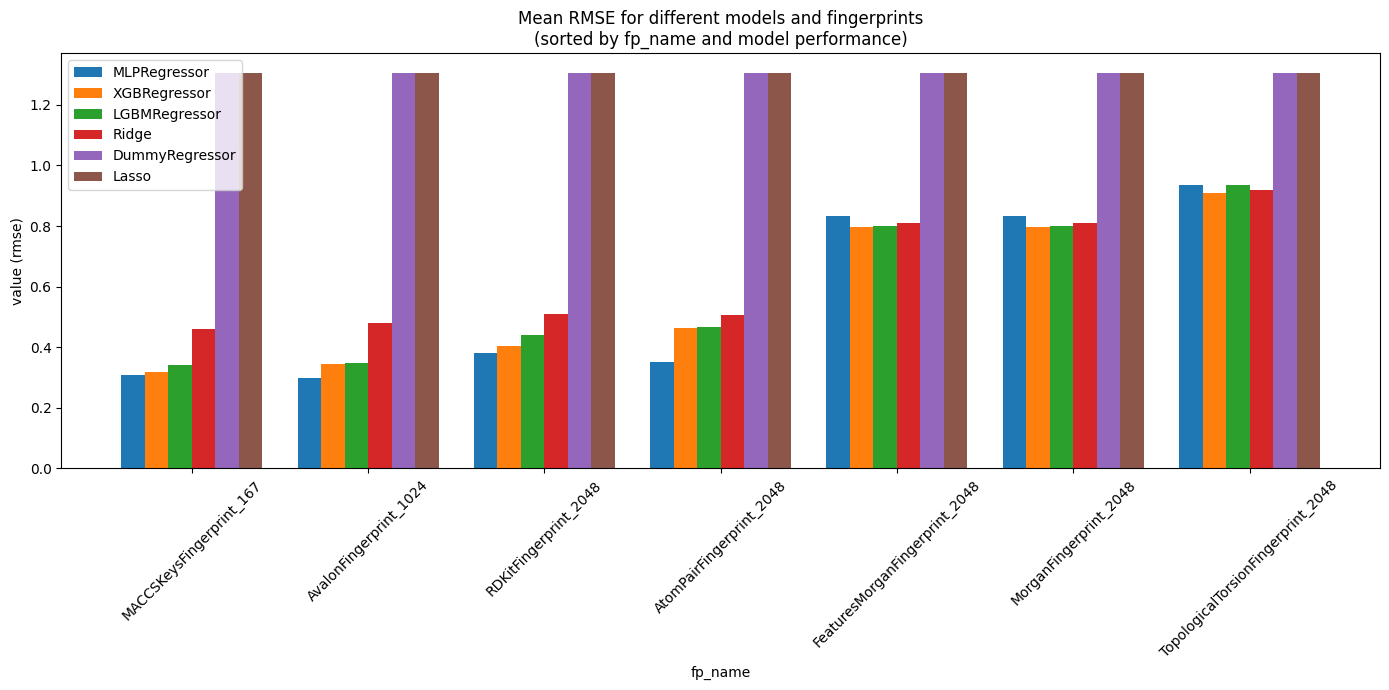

In [ ]:
# --- 1. sort fp_name groups by their mean rmse ---
fp_means = df.groupby("fp_name")["value"].mean().sort_values()
sorted_fps = fp_means.index.tolist()

# --- 2. sort models by mean rmse across all fp_name ---
model_means = df.groupby("model")["value"].mean().sort_values()
sorted_models = model_means.index.tolist()

# --- pivot values ---
pivot_df = df.groupby(["fp_name", "model"])["value"].mean().unstack()

# reorder rows (fps) and columns (models)
pivot_df = pivot_df.loc[sorted_fps, sorted_models]

# --- plotting ---
plt.figure(figsize=(14, 7))

models = sorted_models
n_models = len(models)
x = np.arange(len(sorted_fps))
width = 0.8 / n_models

# plot in the same order for each fp_name
for i, model in enumerate(models):
    plt.bar(
        x + i * width,
        pivot_df[model],
        width=width,
        label=model
    )

plt.xticks(x + width * (n_models - 1) / 2, sorted_fps, rotation=45)
plt.ylabel("value (rmse)")
plt.xlabel("fp_name")
plt.title("Mean RMSE for different models and fingerprints\n(sorted by fp_name and model performance)")
plt.legend()
plt.tight_layout()
plt.show()

## TPE Search with LGBM and 4 best fingerprints

[I 2025-11-24 13:14:22,332] A new study created in memory with name: tpe_search_4_fp_LGBM
[I 2025-11-24 13:14:27,332] Trial 0 finished with value: 0.6976701857629429 and parameters: {'data_representation': 'RDKit_2048', 'model': 'lightgbm.LGBMRegressor', 'lightgbm.LGBMRegressor__random_state': 42, 'lightgbm.LGBMRegressor__verbose': -1, 'lightgbm.LGBMRegressor__n_estimators': 273, 'lightgbm.LGBMRegressor__learning_rate': 0.01699897838270077, 'lightgbm.LGBMRegressor__max_depth': 3, 'lightgbm.LGBMRegressor__min_child_weight': 18, 'lightgbm.LGBMRegressor__subsample': 0.7005575058716045, 'lightgbm.LGBMRegressor__colsample_by_tree': 0.7540362888980228, 'lightgbm.LGBMRegressor__gamma': 0.020584494295802447, 'lightgbm.LGBMRegressor__reg_alpha': 4.8495492608099715, 'lightgbm.LGBMRegressor__reg_lambda': 8.324426408004218}. Best is trial 0 with value: 0.6976701857629429.
[I 2025-11-24 13:14:33,346] Trial 1 finished with value: 0.398439255105539 and parameters: {'data_representation': 'Avalon_1024

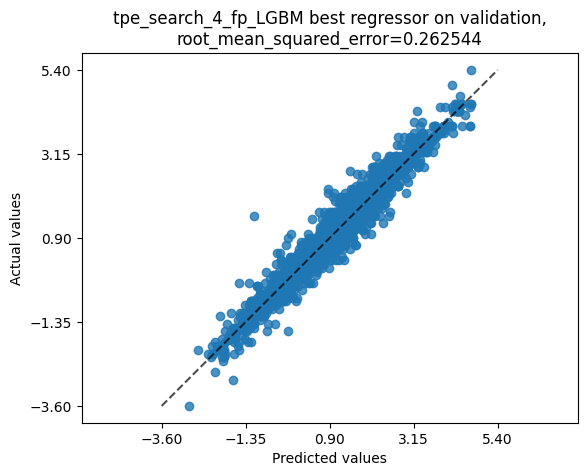


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.27411908343656816
data_representation:
  fp_name_or_path: MACCSKeysFingerprint_167
from_experiment: tpe_search_4_fp_LGBM
model: lightgbm.LGBMRegressor
model_kwargs:
  colsample_by_tree: 0.7135389710575388
  gamma: 0.30860709256160784
  learning_rate: 0.18961721745893234
  max_depth: 8
  min_child_weight: 16
  n_estimators: 1499
  random_state: 42
  reg_alpha: 0.004960447457789119
  reg_lambda: 3.9806144833646058
  subsample: 0.5564148598321396
  verbose: -1
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.24895171529649165
  - 0.2769573584972398
  score_mean: 0.26213908048527373



In [ ]:
with warnings.catch_warnings():
    # lgbm creates column names for features
    # even though no arrays or dataframes are passed as arguments to .fit() method
    warnings.filterwarnings("ignore", category=UserWarning)

    exp = ExperimentOptunaSearchCV("./configs/tpe_search_4_fp_LGBM.yaml").run()

## Grid search, all fingerprints MLP

with early stopping

/usr/local/lib/python3.12/dist-packages/optuna/samplers/_grid.py:232: UserWarning: params contains a value with the type of <class 'dict'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)
[I 2025-11-24 15:08:59,468] A new study created in memory with name: grid_search_4_fp_MLP
[I 2025-11-24 15:09:27,799] Trial 0 finished with value: 0.32235886416826304 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'sklearn.neural_network.MLPRegressor', 'model_kwargs': {'random_state': 42, 'early_stopping': True, 'validation_fraction': 0.25, 'hidden_layer_sizes': [64]}}}. Best is trial 0 with value: 0.32235886416826304.
[I 2025-11-24 15:09:51,178] Trial 1 finished with value: 0.31318927743320046 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'MACCSKeysFingerprint_167'}, 'model': 'sklearn.neural_network.MLPRegres

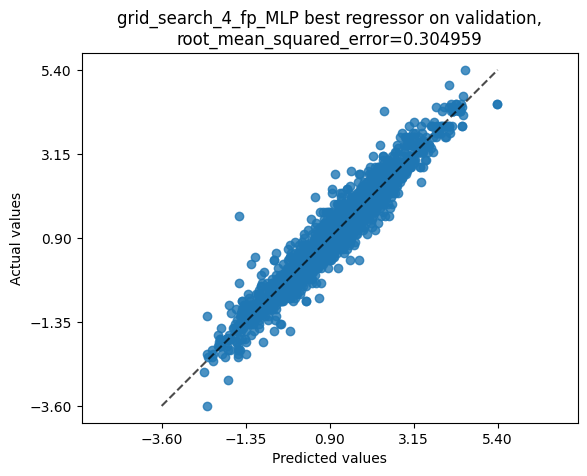


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.31318927743320046
data_representation:
  fp_name_or_path: MACCSKeysFingerprint_167
from_experiment: grid_search_4_fp_MLP
model: sklearn.neural_network.MLPRegressor
model_kwargs:
  early_stopping: true
  hidden_layer_sizes:
  - 128
  random_state: 42
  validation_fraction: 0.25
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.28949600731293224
  - 0.3214149957357275
  score_mean: 0.3044635764478128



In [ ]:
exp = ExperimentGridSearchCV("./configs/grid_search_4_fp_MLP.yaml")
exp.run()

without early stopping

/usr/local/lib/python3.12/dist-packages/optuna/samplers/_grid.py:232: UserWarning: params contains a value with the type of <class 'dict'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)
[I 2025-11-24 15:49:02,161] A new study created in memory with name: grid_search_4_fp_MLP
[I 2025-11-24 15:49:55,670] Trial 0 finished with value: 0.31030585460207527 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'sklearn.neural_network.MLPRegressor', 'model_kwargs': {'random_state': 42, 'hidden_layer_sizes': [64]}}}. Best is trial 0 with value: 0.31030585460207527.
[I 2025-11-24 15:50:46,106] Trial 1 finished with value: 0.30523267690730194 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'MACCSKeysFingerprint_167'}, 'model': 'sklearn.neural_network.MLPRegressor', 'model_kwargs': {'random_state': 42, 'hidden_la

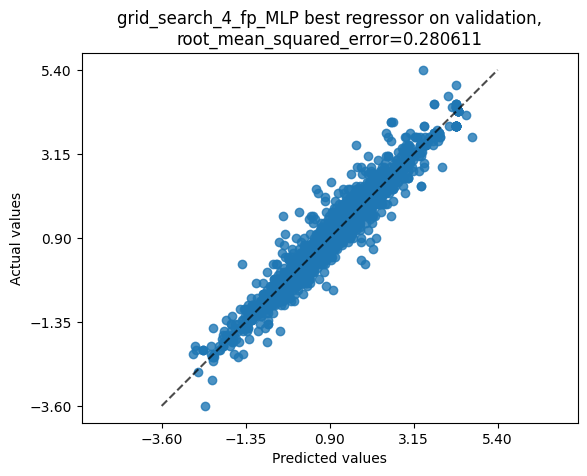


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.29604897552092047
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: grid_search_4_fp_MLP
model: sklearn.neural_network.MLPRegressor
model_kwargs:
  hidden_layer_sizes:
  - 128
  - 32
  random_state: 42
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.26322400751750996
  - 0.2973670250167471
  score_mean: 0.27980024961146044



In [ ]:
exp = ExperimentGridSearchCV("./configs/grid_search_4_fp_MLP.yaml")
exp.run()

In [ ]:
import ast

df = pd.read_csv("./results/grid_search_4_fp_MLP/grid_search_4_fp_MLP_all_trials_results.csv")

df["fp_name"] = df["params"].apply(
    lambda params: ast.literal_eval(params).get('data_representation').get('fp_name_or_path')
)
df["model"] = df["params"].apply(
    lambda params: "MLP_" + "_".join(
        map(str,
            ast.literal_eval(params).get('model_kwargs').get('hidden_layer_sizes')
            )
    )
)
df.drop("params", axis=1, inplace=True)

print(df)

       value                   fp_name       model
0   0.310306    AvalonFingerprint_1024      MLP_64
1   0.305233  MACCSKeysFingerprint_167     MLP_128
2   0.313871    AvalonFingerprint_1024   MLP_64_16
3   0.389275     RDKitFingerprint_2048      MLP_64
4   0.351693  AtomPairFingerprint_2048     MLP_100
5   0.296049    AvalonFingerprint_1024  MLP_128_32
6   0.379662     RDKitFingerprint_2048     MLP_128
7   0.362907  AtomPairFingerprint_2048      MLP_64
8   0.338556  MACCSKeysFingerprint_167   MLP_64_16
9   0.320215  MACCSKeysFingerprint_167  MLP_128_32
10  0.379428     RDKitFingerprint_2048     MLP_100
11  0.367245  AtomPairFingerprint_2048   MLP_64_16
12  0.388546     RDKitFingerprint_2048   MLP_64_16
13  0.375016     RDKitFingerprint_2048  MLP_128_32
14  0.298195    AvalonFingerprint_1024     MLP_128
15  0.347737  AtomPairFingerprint_2048     MLP_128
16  0.318304  MACCSKeysFingerprint_167      MLP_64
17  0.307252  MACCSKeysFingerprint_167     MLP_100
18  0.299843    AvalonFingerpri

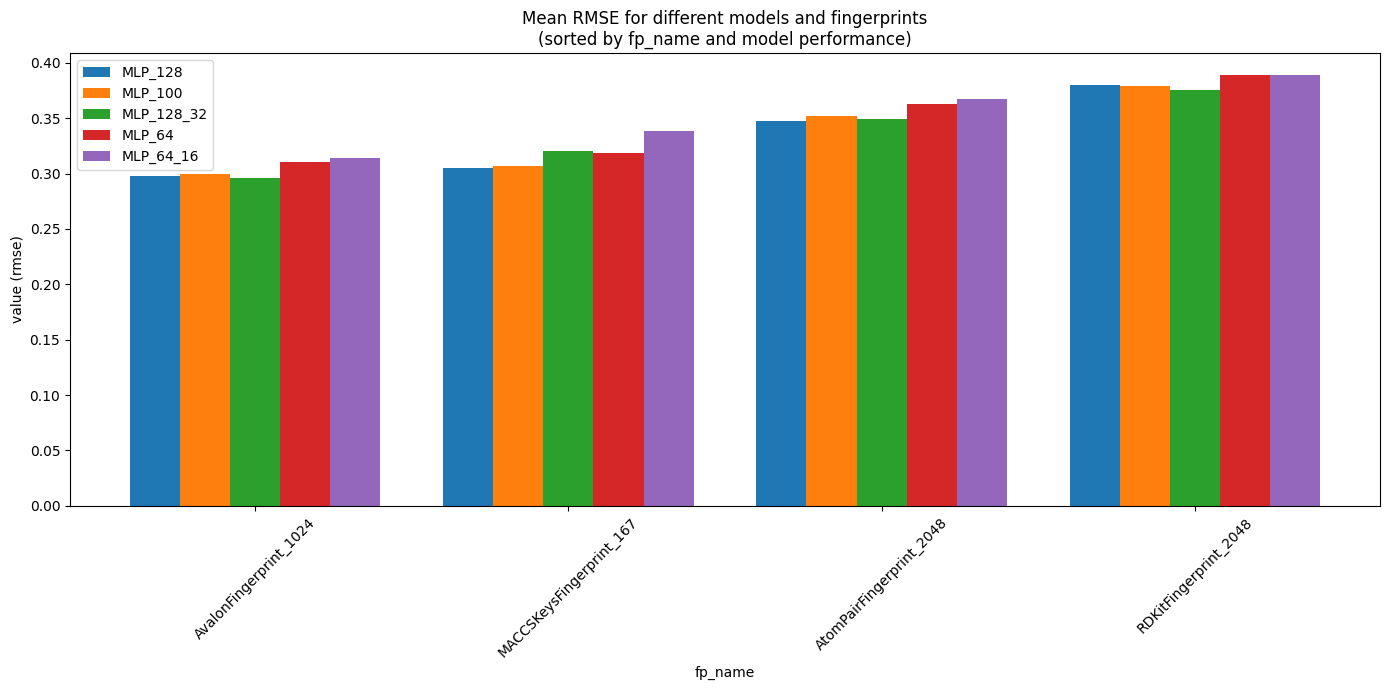

In [ ]:
# --- 1. sort fp_name groups by their mean rmse ---
fp_means = df.groupby("fp_name")["value"].mean().sort_values()
sorted_fps = fp_means.index.tolist()

# --- 2. sort models by mean rmse across all fp_name ---
model_means = df.groupby("model")["value"].mean().sort_values()
sorted_models = model_means.index.tolist()

# --- pivot values ---
pivot_df = df.groupby(["fp_name", "model"])["value"].mean().unstack()

# reorder rows (fps) and columns (models)
pivot_df = pivot_df.loc[sorted_fps, sorted_models]

# --- plotting ---
plt.figure(figsize=(14, 7))

models = sorted_models
n_models = len(models)
x = np.arange(len(sorted_fps))
width = 0.8 / n_models

# plot in the same order for each fp_name
for i, model in enumerate(models):
    plt.bar(
        x + i * width,
        pivot_df[model],
        width=width,
        label=model
    )

plt.xticks(x + width * (n_models - 1) / 2, sorted_fps, rotation=45)
plt.ylabel("value (rmse)")
plt.xlabel("fp_name")
plt.title("Mean RMSE for different models and fingerprints\n(sorted by fp_name and model performance)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import preprocessing
temp_X_train = preprocessing._data_cache['AvalonFingerprint_1024']["X_train"]
temp_y_train = preprocessing._data_cache['_y']['y_train']

In [ ]:
import copy
from experiment_utils import _load_and_configure_regressor
temp_config = copy.deepcopy(exp.results["best_params"])
temp_config["model_kwargs"]["early_stopping"] = True
temp_config["model_kwargs"]["validation_fraction"] = 0.2
temp_config["model_kwargs"]["n_iter_no_change"]=200
temp_MLP = _load_and_configure_regressor(
    model=temp_config["model"],
    model_kwargs=temp_config["model_kwargs"],
)
temp_MLP

TransformedTargetRegressor(regressor=MLPRegressor(early_stopping=True,
                                                  hidden_layer_sizes=[128, 32],
                                                  n_iter_no_change=200,
                                                  random_state=42,
                                                  validation_fraction=0.2),
                           transformer=StandardScaler())

In [ ]:
temp_MLP.fit(temp_X_train, temp_y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


TransformedTargetRegressor(regressor=MLPRegressor(early_stopping=True,
                                                  hidden_layer_sizes=[128, 32],
                                                  n_iter_no_change=200,
                                                  random_state=42,
                                                  validation_fraction=0.2),
                           transformer=StandardScaler())

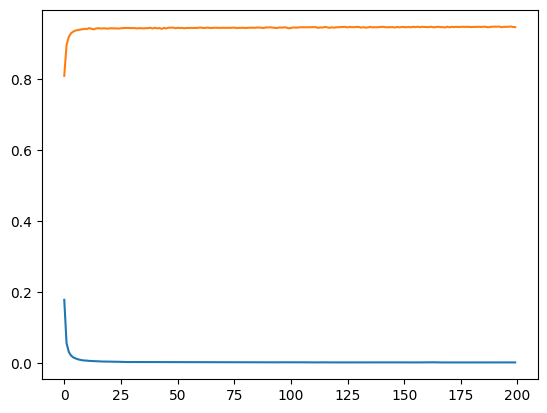

In [ ]:
plt.figure()
plt.plot(temp_MLP.regressor_.loss_curve_)
plt.plot(temp_MLP.regressor_.validation_scores_)
plt.show()

## Tpe search avalon MLP

[I 2025-11-24 19:35:14,292] A new study created in memory with name: tpe_search_avalon_MLP
[I 2025-11-24 19:36:31,191] Trial 0 finished with value: 0.29572150237455413 and parameters: {'data_representation': 'Avalon_1024', 'model': 'sklearn.neural_network.MLPRegressor', 'sklearn.neural_network.MLPRegressor__random_state': 42, 'sklearn.neural_network.MLPRegressor__early_stopping': True, 'sklearn.neural_network.MLPRegressor__hidden_layer_sizes': [128, 32], 'sklearn.neural_network.MLPRegressor__activation': 'tanh', 'sklearn.neural_network.MLPRegressor__alpha': 0.02465832945854911, 'sklearn.neural_network.MLPRegressor__learning_rate_init': 0.0024810409748678114}. Best is trial 0 with value: 0.29572150237455413.
[I 2025-11-24 19:37:12,761] Trial 1 finished with value: 0.32796338008253884 and parameters: {'data_representation': 'Avalon_1024', 'model': 'sklearn.neural_network.MLPRegressor', 'sklearn.neural_network.MLPRegressor__random_state': 42, 'sklearn.neural_network.MLPRegressor__early_st

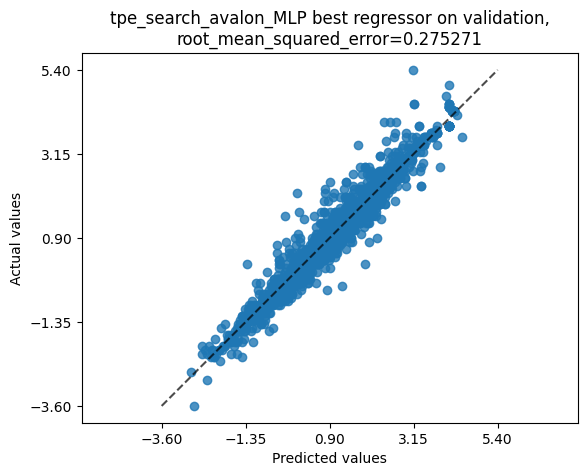


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.28150307424193877
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: tpe_search_avalon_MLP
model: sklearn.neural_network.MLPRegressor
model_kwargs:
  activation: relu
  alpha: 0.03318172821968537
  early_stopping: true
  hidden_layer_sizes:
  - 128
  - 32
  learning_rate_init: 0.0009501214996257317
  random_state: 42
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.2575660441278428
  - 0.291607537338953
  score_mean: 0.27462208342008454



In [ ]:
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Choices for a categorical distribution should be a tuple"
    )
    exp = ExperimentOptunaSearchCV("./configs/tpe_search_avalon_MLP.yaml").run()

## GRID Search avalon MLP architectures

/usr/local/lib/python3.12/dist-packages/optuna/samplers/_grid.py:232: UserWarning: params contains a value with the type of <class 'dict'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)
[I 2025-11-24 20:45:24,361] A new study created in memory with name: grid_search_avalon_MLP_architectures
[I 2025-11-24 20:46:37,469] Trial 0 finished with value: 0.28486620018615405 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'sklearn.neural_network.MLPRegressor', 'model_kwargs': {'random_state': 42, 'early_stopping': True, 'hidden_layer_sizes': [128, 128], 'alpha': 0.033, 'learning_rate_init': 0.00095}}}. Best is trial 0 with value: 0.28486620018615405.
[I 2025-11-24 20:50:39,075] Trial 1 finished with value: 0.27646916236733526 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'mod

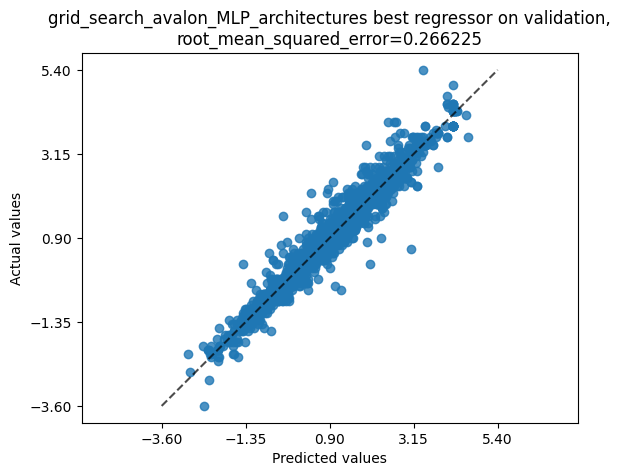


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.2727707369372057
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: grid_search_avalon_MLP_architectures
model: sklearn.neural_network.MLPRegressor
model_kwargs:
  alpha: 0.033
  early_stopping: true
  hidden_layer_sizes:
  - 512
  learning_rate_init: 0.00095
  random_state: 42
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.24767694459320028
  - 0.2832368983257597
  score_mean: 0.2653969233443603



In [ ]:
exp = ExperimentGridSearchCV("./configs/grid_search_avalon_MLP_architectures.yaml")
exp.run()

In [ ]:
import ast

df = pd.read_csv("./results/grid_search_avalon_MLP_architectures/grid_search_avalon_MLP_architectures_all_trials_results.csv")

df["fp_name"] = df["params"].apply(
    lambda params: ast.literal_eval(params).get('data_representation').get('fp_name_or_path')
)
df["model"] = df["params"].apply(
    lambda params: "MLP_" + "_".join(
        map(str,
            ast.literal_eval(params).get('model_kwargs').get('hidden_layer_sizes')
            )
    )
)
df.drop("params", axis=1, inplace=True)

print(df.sort_values("value"))

      value                 fp_name        model
7  0.272771  AvalonFingerprint_1024      MLP_512
6  0.275351  AvalonFingerprint_1024      MLP_256
2  0.275429  AvalonFingerprint_1024  MLP_512_512
1  0.276469  AvalonFingerprint_1024  MLP_512_128
8  0.278454  AvalonFingerprint_1024   MLP_256_64
3  0.279573  AvalonFingerprint_1024  MLP_256_256
4  0.281757  AvalonFingerprint_1024   MLP_128_32
0  0.284866  AvalonFingerprint_1024  MLP_128_128
5  0.287109  AvalonFingerprint_1024      MLP_128


## Test tensorflow MLP

/usr/local/lib/python3.12/dist-packages/optuna/samplers/_grid.py:232: UserWarning: params contains a value with the type of <class 'dict'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)
[I 2025-11-25 19:48:23,614] A new study created in memory with name: test_grid_TFMLP



running experiment with config: ./configs/test_grid_TFMLP.yaml



[I 2025-11-25 19:48:30,871] Trial 0 finished with value: 0.3193667836845142 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'tf_models.OptimizedTFMLPRegressor', 'model_kwargs': {'random_state': 42, 'hidden_layer_sizes': [128, 32]}}}. Best is trial 0 with value: 0.3193667836845142.
[I 2025-11-25 19:48:36,755] Trial 1 finished with value: 0.33483439970131657 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'tf_models.OptimizedTFMLPRegressor', 'model_kwargs': {'random_state': 42, 'hidden_layer_sizes': [100]}}}. Best is trial 0 with value: 0.3193667836845142.


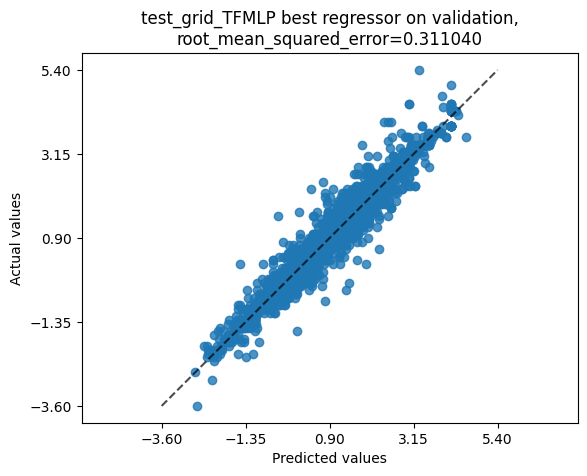


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.3193667836845142
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: test_grid_TFMLP
model: tf_models.OptimizedTFMLPRegressor
model_kwargs:
  hidden_layer_sizes:
  - 128
  - 32
  random_state: 42
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.2950477407479698
  - 0.32751309858161687
  score_mean: 0.3103179277655148



In [ ]:
# 21 seconds on T4
exp = run_hp_search_experiment("./configs/test_grid_TFMLP.yaml")

## Test torch MLP

In [ ]:
!pip install lightning -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 64.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/optuna/samplers/_grid.py:232: UserWarning: params contains a value with the type of <class 'dict'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)
[I 2025-11-25 19:47:27,154] A new study created in memory with name: test_grid_torch_MLP



running experiment with config: ./configs/test_grid_Torch_MLP.yaml



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
[I 2025-11-25 19:47:45,038] Trial 0 finished with value: 0.3171674079010304 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'torch_models.FastPLMLPRegressor', 'model_kwargs': {'random_state': 42, 'hidden_layer_sizes': [128, 32]}}}. Best is trial 0 with value: 0.3171674079010304.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-lo

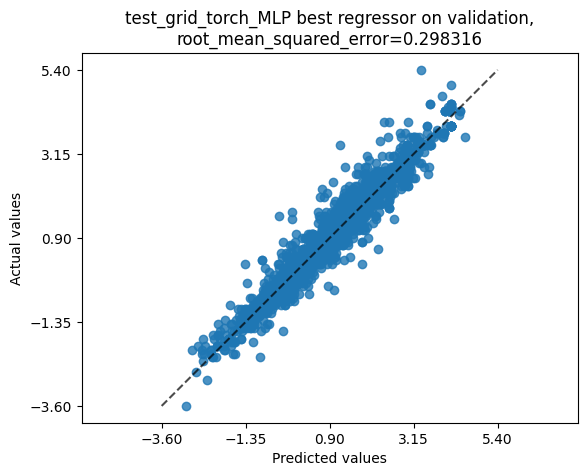


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.3171674079010304
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: test_grid_torch_MLP
model: torch_models.FastPLMLPRegressor
model_kwargs:
  hidden_layer_sizes:
  - 128
  - 32
  random_state: 42
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.28176636274045463
  - 0.31464342234113135
  score_mean: 0.2977917041721694



In [ ]:
# 27 seconds on T4
exp = run_hp_search_experiment("./configs/test_grid_Torch_MLP.yaml")

tensorflow seem to perform slightly better than torch, but i struggle to run tensorflow on GPU on my laptop

In [ ]:
!git pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 794 bytes | 794.00 KiB/s, done.
From https://github.com/mvgolubev99/kaggle-chemical-structure-and-logp
   ab1d600..c466214  dev        -> origin/dev
Updating ab1d600..c466214
Fast-forward
 configs/tpe_search_Torch_MLP.yaml | 48 +++++++++++++++++++++++++++++++++++++++
 1 file changed, 48 insertions(+)
 create mode 100644 configs/tpe_search_Torch_MLP.yaml


[I 2025-11-25 20:24:40,849] A new study created in memory with name: tpe_search_Torch_MLP
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



running experiment with config: ./configs/tpe_search_Torch_MLP.yaml



[I 2025-11-25 20:24:51,788] Trial 0 finished with value: 0.3341580069134072 and parameters: {'data_representation': 'fp_1', 'model': 'torch_models.FastPLMLPRegressor', 'torch_models.FastPLMLPRegressor__random_state': 42, 'torch_models.FastPLMLPRegressor__hidden_layer_sizes': [768, 256], 'torch_models.FastPLMLPRegressor__learning_rate': 0.013311216080736894, 'torch_models.FastPLMLPRegressor__weight_decay': 1.2087541473056957e-05, 'torch_models.FastPLMLPRegressor__batch_size': 32, 'torch_models.FastPLMLPRegressor__activation': 'leaky_relu'}. Best is trial 0 with value: 0.3341580069134072.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCA

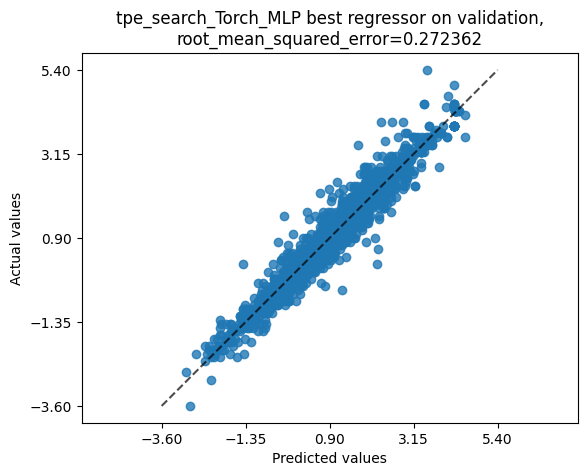


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.2769006537448779
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: tpe_search_Torch_MLP
model: torch_models.FastPLMLPRegressor
model_kwargs:
  activation: leaky_relu
  batch_size: 32
  hidden_layer_sizes:
  - 768
  - 256
  learning_rate: 0.00025693975203778787
  random_state: 42
  weight_decay: 9.305750630647072e-05
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.257099837623429
  - 0.28784498017583543
  score_mean: 0.27175216679918096



In [ ]:
exp = run_hp_search_experiment("./configs/tpe_search_Torch_MLP.yaml")

In [ ]:
df = pd.read_csv("/content/kaggle-chemical-structure-and-logp/results/tpe_search_Torch_MLP/tpe_search_Torch_MLP_all_trials_results.csv")

In [ ]:
df

,data_representation,model,torch_models.FastPLMLPRegressor__random_state,torch_models.FastPLMLPRegressor__hidden_layer_sizes,torch_models.FastPLMLPRegressor__learning_rate,torch_models.FastPLMLPRegressor__weight_decay,torch_models.FastPLMLPRegressor__batch_size,torch_models.FastPLMLPRegressor__activation,value
0,fp_1,torch_models.FastPLMLPRegressor,42,"[768, 256]",0.013311,0.000012,32,leaky_relu,0.334158
1,fp_1,torch_models.FastPLMLPRegressor,42,"[128, 32, 16]",0.000397,0.001140,128,leaky_relu,0.322819
2,fp_1,torch_models.FastPLMLPRegressor,42,[768],0.053452,0.000108,32,leaky_relu,0.445185
3,fp_1,torch_models.FastPLMLPRegressor,42,"[768, 256]",0.001466,0.000122,32,leaky_relu,0.292024
4,fp_1,torch_models.FastPLMLPRegressor,42,"[768, 256]",0.000167,0.000272,64,leaky_relu,0.286962
...,...,...,...,...,...,...,...,...,...
507,fp_1,torch_models.FastPLMLPRegressor,42,"[768, 256]",0.000262,0.000033,32,leaky_relu,0.280198
508,fp_1,torch_models.FastPLMLPRegressor,42,"[768, 256]",0.000334,0.000042,32,leaky_relu,0.279455
509,fp_1,torch_models.FastPLMLPRegressor,42,"[768, 256]",0.000230,0.000062,32,leaky_relu,0.280823
510,fp_1,torch_models.FastPLMLPRegressor,42,"[768, 256]",0.000275,0.000078,32,leaky_relu,0.279746


In [ ]:
df.drop(["data_representation", "torch_models.FastPLMLPRegressor__random_state"], axis=1, inplace=True)

In [ ]:
df.sort_values(by="value", inplace=True)

In [ ]:
df

,model,torch_models.FastPLMLPRegressor__hidden_layer_sizes,torch_models.FastPLMLPRegressor__learning_rate,torch_models.FastPLMLPRegressor__weight_decay,torch_models.FastPLMLPRegressor__batch_size,torch_models.FastPLMLPRegressor__activation,value
216,torch_models.FastPLMLPRegressor,"[768, 256]",0.000257,0.000093,32,leaky_relu,0.276901
307,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000055,32,leaky_relu,0.277047
462,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000060,32,leaky_relu,0.277387
399,torch_models.FastPLMLPRegressor,"[768, 256]",0.000253,0.000069,32,leaky_relu,0.277579
407,torch_models.FastPLMLPRegressor,"[768, 256]",0.000279,0.000074,32,leaky_relu,0.277801
...,...,...,...,...,...,...,...
432,torch_models.FastPLMLPRegressor,"[512, 256, 16]",0.029537,0.008533,32,relu,0.534301
359,torch_models.FastPLMLPRegressor,"[768, 256]",0.005964,0.087145,32,leaky_relu,0.573276
58,torch_models.FastPLMLPRegressor,[128],0.005658,0.098756,32,leaky_relu,0.584379
33,torch_models.FastPLMLPRegressor,"[128, 32, 16]",0.081497,0.000013,32,leaky_relu,2.665003


In [ ]:
df.columns = list(map(
    lambda s: s.rsplit("__", 1)[1] if "__" in s else s,
    df.columns.to_list(),
))
df

,model,hidden_layer_sizes,learning_rate,weight_decay,batch_size,activation,value
216,torch_models.FastPLMLPRegressor,"[768, 256]",0.000257,0.000093,32,leaky_relu,0.276901
307,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000055,32,leaky_relu,0.277047
462,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000060,32,leaky_relu,0.277387
399,torch_models.FastPLMLPRegressor,"[768, 256]",0.000253,0.000069,32,leaky_relu,0.277579
407,torch_models.FastPLMLPRegressor,"[768, 256]",0.000279,0.000074,32,leaky_relu,0.277801
...,...,...,...,...,...,...,...
432,torch_models.FastPLMLPRegressor,"[512, 256, 16]",0.029537,0.008533,32,relu,0.534301
359,torch_models.FastPLMLPRegressor,"[768, 256]",0.005964,0.087145,32,leaky_relu,0.573276
58,torch_models.FastPLMLPRegressor,[128],0.005658,0.098756,32,leaky_relu,0.584379
33,torch_models.FastPLMLPRegressor,"[128, 32, 16]",0.081497,0.000013,32,leaky_relu,2.665003


In [ ]:
import ast

df["hidden_layers"] = df["hidden_layer_sizes"].apply(
    lambda x: len(ast.literal_eval(x))
)
df["first_hidden_layer_dim"] = df["hidden_layer_sizes"].apply(
    lambda x: ast.literal_eval(x)[0]
)

In [ ]:
df

,model,hidden_layer_sizes,learning_rate,weight_decay,batch_size,activation,value,hidden_layers,first_hidden_layer_dim
216,torch_models.FastPLMLPRegressor,"[768, 256]",0.000257,0.000093,32,leaky_relu,0.276901,2,768
307,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000055,32,leaky_relu,0.277047,2,768
462,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000060,32,leaky_relu,0.277387,2,768
399,torch_models.FastPLMLPRegressor,"[768, 256]",0.000253,0.000069,32,leaky_relu,0.277579,2,768
407,torch_models.FastPLMLPRegressor,"[768, 256]",0.000279,0.000074,32,leaky_relu,0.277801,2,768
...,...,...,...,...,...,...,...,...,...
432,torch_models.FastPLMLPRegressor,"[512, 256, 16]",0.029537,0.008533,32,relu,0.534301,3,512
359,torch_models.FastPLMLPRegressor,"[768, 256]",0.005964,0.087145,32,leaky_relu,0.573276,2,768
58,torch_models.FastPLMLPRegressor,[128],0.005658,0.098756,32,leaky_relu,0.584379,1,128
33,torch_models.FastPLMLPRegressor,"[128, 32, 16]",0.081497,0.000013,32,leaky_relu,2.665003,3,128


In [ ]:
df.head(32)

,model,hidden_layer_sizes,learning_rate,weight_decay,batch_size,activation,value,hidden_layers,first_hidden_layer_dim
216,torch_models.FastPLMLPRegressor,"[768, 256]",0.000257,0.000093,32,leaky_relu,0.276901,2,768
307,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000055,32,leaky_relu,0.277047,2,768
462,torch_models.FastPLMLPRegressor,"[768, 256]",0.000263,0.000060,32,leaky_relu,0.277387,2,768
399,torch_models.FastPLMLPRegressor,"[768, 256]",0.000253,0.000069,32,leaky_relu,0.277579,2,768
407,torch_models.FastPLMLPRegressor,"[768, 256]",0.000279,0.000074,32,leaky_relu,0.277801,2,768
132,torch_models.FastPLMLPRegressor,"[768, 256]",0.000280,0.000031,32,leaky_relu,0.277876,2,768
436,torch_models.FastPLMLPRegressor,"[768, 256]",0.000277,0.000094,32,leaky_relu,0.277877,2,768
393,torch_models.FastPLMLPRegressor,"[768, 256]",0.000314,0.000088,32,leaky_relu,0.278052,2,768
305,torch_models.FastPLMLPRegressor,"[768, 256]",0.000270,0.000054,32,leaky_relu,0.278090,2,768
332,torch_models.FastPLMLPRegressor,"[768, 256]",0.000277,0.000039,32,leaky_relu,0.278101,2,768


In [ ]:
df.groupby(by="hidden_layer_sizes")["value"].min().sort_values()

,value
hidden_layer_sizes,
"[768, 256]",0.276901
[768],0.278822
"[768, 256, 16]",0.279666
"[512, 256]",0.280581
"[512, 256, 16]",0.283396
[512],0.285993
"[128, 32]",0.297401
[128],0.299612
"[128, 32, 16]",0.299639


In [ ]:
df.groupby(by="hidden_layers")["value"].min().sort_values()

,value
hidden_layers,
2,0.276901
1,0.278822
3,0.279666


In [ ]:
df.groupby(by="first_hidden_layer_dim")["value"].min().sort_values()

,value
first_hidden_layer_dim,
768,0.276901
512,0.280581
128,0.297401


In [ ]:
df.groupby(by="batch_size")["value"].min().sort_values()

,value
batch_size,
32,0.276901
64,0.283838
128,0.283899
512,0.287443


In [ ]:
df.groupby(by="activation")["value"].min().sort_values()

,value
activation,
leaky_relu,0.276901
relu,0.278592


In [ ]:
!git pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 773 bytes | 773.00 KiB/s, done.
From https://github.com/mvgolubev99/kaggle-chemical-structure-and-logp
   c466214..1f488ee  dev        -> origin/dev
Updating c466214..1f488ee
Fast-forward
 configs/grid_search_avalon_Torch_MLP.yaml | 37 +++++++++++++++++++++++++++++++
 1 file changed, 37 insertions(+)
 create mode 100644 configs/grid_search_avalon_Torch_MLP.yaml


/usr/local/lib/python3.12/dist-packages/optuna/samplers/_grid.py:232: UserWarning: params contains a value with the type of <class 'dict'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)
[I 2025-11-25 23:18:54,702] A new study created in memory with name: grid_search_avalon_Torch_MLP
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



running experiment with config: ./configs/grid_search_avalon_Torch_MLP.yaml



[I 2025-11-25 23:19:16,552] Trial 0 finished with value: 0.3099861255677938 and parameters: {'params': {'data_representation': {'fp_name_or_path': 'AvalonFingerprint_1024'}, 'model': 'torch_models.FastPLMLPRegressor', 'model_kwargs': {'random_state': 42, 'hidden_layer_sizes': [128, 128], 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'batch_size': 32, 'activation': 'relu'}}}. Best is trial 0 with value: 0.3099861255677938.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
[I 2025-11-25 23:19:38,602] Trial 1 finished with value: 0.2879913966277544 and parameters: {'params': {'data_representation': 

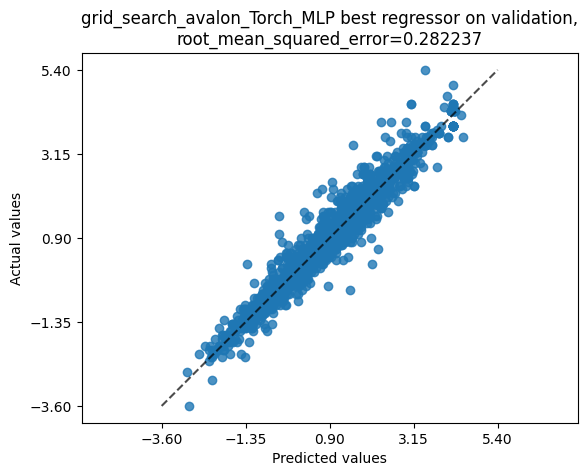


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.28722843026853
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: grid_search_avalon_Torch_MLP
model: torch_models.FastPLMLPRegressor
model_kwargs:
  activation: relu
  batch_size: 32
  hidden_layer_sizes:
  - 1024
  - 1024
  learning_rate: 0.0001
  random_state: 42
  weight_decay: 0.0001
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.265820862045449
  - 0.2983965596673959
  score_mean: 0.2815267787595539



In [ ]:
exp = run_hp_search_experiment("./configs/grid_search_avalon_Torch_MLP.yaml")

In [ ]:
!git pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 805 bytes | 805.00 KiB/s, done.
From https://github.com/mvgolubev99/kaggle-chemical-structure-and-logp
   1f488ee..90e8868  dev        -> origin/dev
Updating 1f488ee..90e8868
Fast-forward
 configs/tpe_search_avalon_Torch_MLP_1024_1024.yaml | 41 ++++++++++++++++++++++
 1 file changed, 41 insertions(+)
 create mode 100644 configs/tpe_search_avalon_Torch_MLP_1024_1024.yaml


[I 2025-11-25 23:30:29,606] A new study created in memory with name: tpe_search_avalon_Torch_MLP_1024_1024
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



running experiment with config: ./configs/tpe_search_avalon_Torch_MLP_1024_1024.yaml



[I 2025-11-25 23:30:38,456] Trial 0 finished with value: 1.326967384738443 and parameters: {'data_representation': 'fp_1', 'model': 'torch_models.FastPLMLPRegressor', 'torch_models.FastPLMLPRegressor__random_state': 42, 'torch_models.FastPLMLPRegressor__hidden_layer_sizes': [1024, 1024], 'torch_models.FastPLMLPRegressor__learning_rate': 0.0013292918943162175, 'torch_models.FastPLMLPRegressor__weight_decay': 0.566984951147885, 'torch_models.FastPLMLPRegressor__dropout_rate': 0.0, 'torch_models.FastPLMLPRegressor__batch_size': 32, 'torch_models.FastPLMLPRegressor__activation': 'relu'}. Best is trial 0 with value: 1.326967384738443.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
I

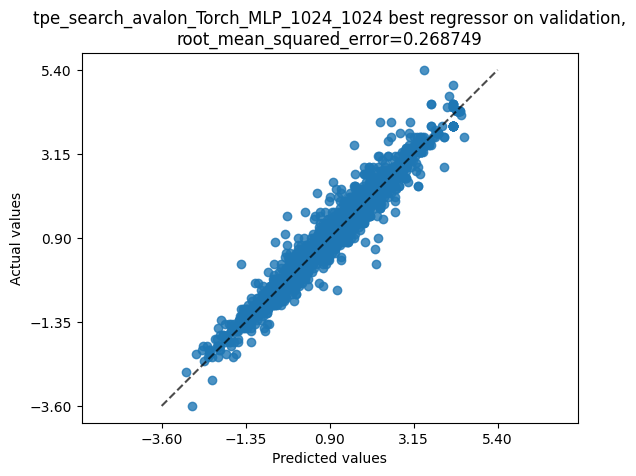


--------------------
best params with best_cv_score and val_score:

cv_score:
  scoring: neg_root_mean_squared_error
  value: 0.27679425942827157
data_representation:
  fp_name_or_path: AvalonFingerprint_1024
from_experiment: tpe_search_avalon_Torch_MLP_1024_1024
model: torch_models.FastPLMLPRegressor
model_kwargs:
  activation: relu
  batch_size: 32
  dropout_rate: 0.0
  hidden_layer_sizes:
  - 1024
  - 1024
  learning_rate: 0.0002625976867968248
  random_state: 42
  weight_decay: 1.7114562344413445e-05
val_score:
  metric_name: root_mean_squared_error
  score_CI:
  - 0.25293512733316964
  - 0.28494065399187046
  score_mean: 0.26817225437837217



In [ ]:
exp = run_hp_search_experiment("./configs/tpe_search_avalon_Torch_MLP_1024_1024.yaml")

In [ ]:
import preprocessing
temp_X_train = preprocessing._data_cache['AvalonFingerprint_1024']["X_train"]
temp_y_train = preprocessing._data_cache['_y']['y_train']

In [ ]:
import copy
from experiment_utils import _load_and_configure_regressor
temp_config = copy.deepcopy(exp.results["best_params"])
temp_config["model_kwargs"]["epochs"] = 200

temp_MLP = _load_and_configure_regressor(
    model=temp_config["model"],
    model_kwargs=temp_config["model_kwargs"],
)
temp_MLP

TransformedTargetRegressor(regressor=FastPLMLPRegressor(batch_size=32,
                                                        epochs=200,
                                                        hidden_layer_sizes=[1024,
                                                                            1024],
                                                        learning_rate=0.0002625976867968248,
                                                        weight_decay=1.7114562344413445e-05),
                           transformer=StandardScaler())

In [ ]:
temp_MLP.fit(temp_X_train, temp_y_train)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TransformedTargetRegressor(regressor=FastPLMLPRegressor(batch_size=32,
                                                        epochs=200,
                                                        hidden_layer_sizes=[1024,
                                                                            1024],
                                                        learning_rate=0.0002625976867968248,
                                                        weight_decay=1.7114562344413445e-05),
                           transformer=StandardScaler())

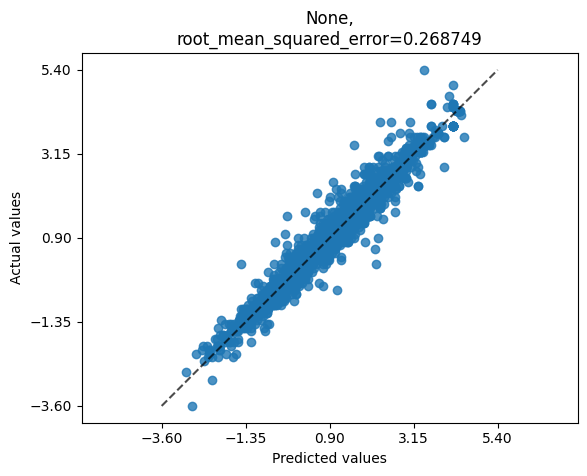

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.26817225437837217, 'score_CI': [0.25293512733316964, 0.28494065399187046]}


In [ ]:
import utils

utils.parity_plot(
    estimator=temp_MLP,
    X=preprocessing._data_cache['AvalonFingerprint_1024']["X_val"],
    y_true=preprocessing._data_cache['_y']['y_val'],
)

print(utils.bootstrap_score(
        estimator=temp_MLP,
        X=preprocessing._data_cache['AvalonFingerprint_1024']["X_val"],
        y_true=preprocessing._data_cache['_y']['y_val'],
    ))

In [ ]:
import preprocessing
temp_X_train = preprocessing._data_cache['AvalonFingerprint_1024']["X_train"]
temp_y_train = preprocessing._data_cache['_y']['y_train']

In [ ]:
import copy
from experiment_utils import _load_and_configure_regressor
temp_config = copy.deepcopy(exp.results["best_params"])
temp_config["model_kwargs"]["epochs"] = 1000
temp_config["model_kwargs"]["dropout_rate"]=0.25

temp_MLP = _load_and_configure_regressor(
    model=temp_config["model"],
    model_kwargs=temp_config["model_kwargs"],
)
temp_MLP

TransformedTargetRegressor(regressor=FastPLMLPRegressor(batch_size=32,
                                                        dropout_rate=0.25,
                                                        epochs=1000,
                                                        hidden_layer_sizes=[1024,
                                                                            1024],
                                                        learning_rate=0.0002625976867968248,
                                                        weight_decay=1.7114562344413445e-05),
                           transformer=StandardScaler())

In [ ]:
temp_MLP.fit(temp_X_train, temp_y_train)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TransformedTargetRegressor(regressor=FastPLMLPRegressor(batch_size=32,
                                                        dropout_rate=0.25,
                                                        epochs=1000,
                                                        hidden_layer_sizes=[1024,
                                                                            1024],
                                                        learning_rate=0.0002625976867968248,
                                                        weight_decay=1.7114562344413445e-05),
                           transformer=StandardScaler())

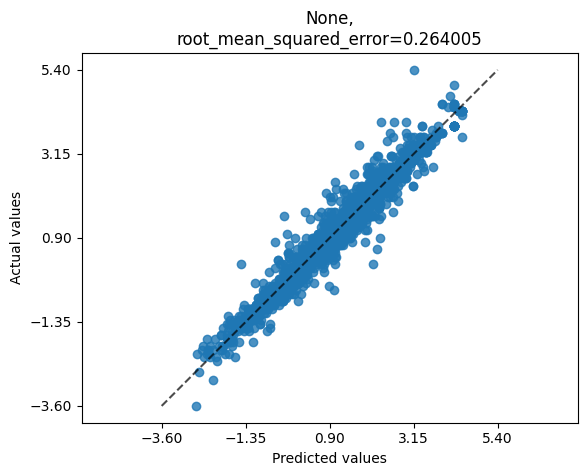

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.26328954832281615, 'score_CI': [0.2475532830411951, 0.2796959362794481]}


In [ ]:
import utils

utils.parity_plot(
    estimator=temp_MLP,
    X=preprocessing._data_cache['AvalonFingerprint_1024']["X_val"],
    y_true=preprocessing._data_cache['_y']['y_val'],
)

print(utils.bootstrap_score(
        estimator=temp_MLP,
        X=preprocessing._data_cache['AvalonFingerprint_1024']["X_val"],
        y_true=preprocessing._data_cache['_y']['y_val'],
    ))

In [31]:
import experiment_utils
import utils
import preprocessing

def train_and_eval(model, model_kwargs, data):
    X_train, y_train = data["train"]
    X_val, y_val = data["val"]

    model = experiment_utils._load_and_configure_regressor(
        model=model,
        model_kwargs=model_kwargs
    )

    model.fit(X_train, y_train)

    utils.parity_plot(
        estimator=model,
        X=X_train,
        y_true=y_train,
        title="on train",
    )

    print(utils.bootstrap_score(
            estimator=model,
            X=X_train,
            y_true=y_train,
        ))

    utils.parity_plot(
        estimator=model,
        X=X_val,
        y_true=y_val,
        title="on val",
    )

    print(utils.bootstrap_score(
            estimator=model,
            X=X_val,
            y_true=y_val,
        ))
    
    return model

In [32]:
data = preprocessing._load_and_preprocess(fp_name_or_path="AvalonFingerprint_1024")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. C

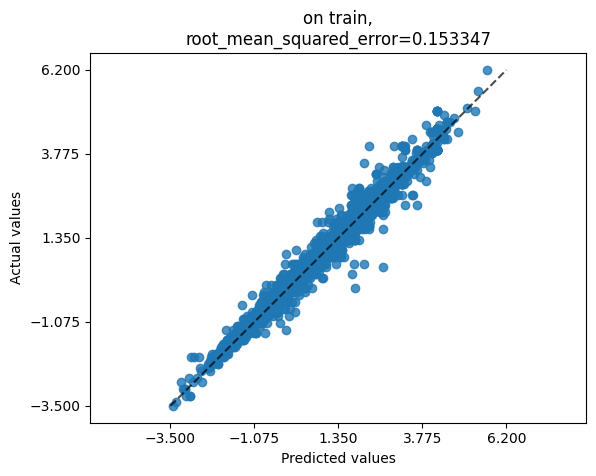

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.15347734674969313, 'score_CI': [0.14579518629504, 0.16148724593580596]}


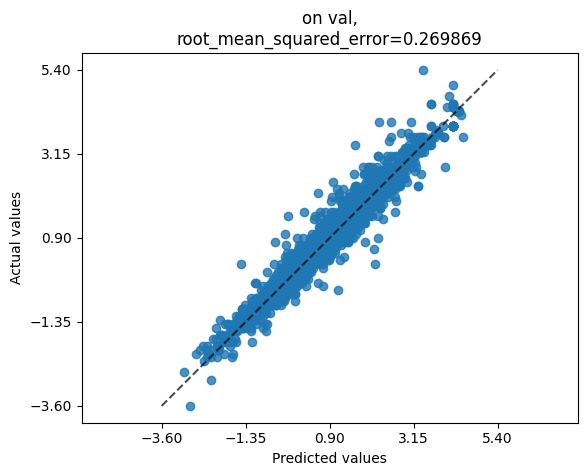

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.26929166256278336, 'score_CI': [0.25402418404451743, 0.2859425439934283]}


In [33]:
model="torch_models.FastPLMLPRegressor"

model_kwargs={
    "activation": "relu",
    "batch_size": 32,
    "hidden_layer_sizes": [1024, 1024],
    "learning_rate": 0.0002625976867968248,
    "weight_decay": 1.7114562344413445e-05,
}

fitted_model = train_and_eval(model, model_kwargs, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.0, 'use_batchnorm': False, 'epochs': 1000, 'hidden_layer_sizes': [1024, 1024], 'learning_rate': 0.0002, 'weight_decay': 2e-05}


/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


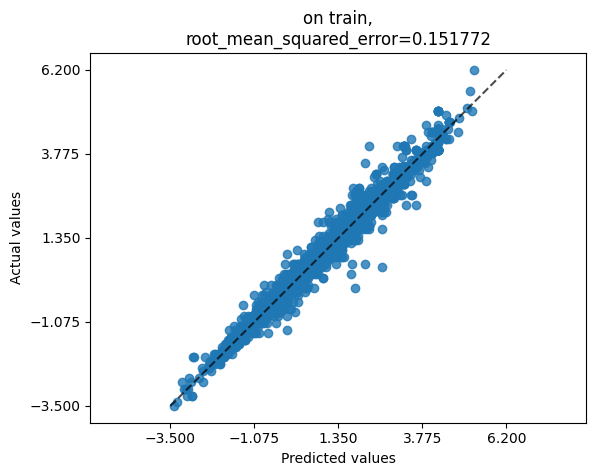

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.1518868250457434, 'score_CI': [0.14414705040360032, 0.15977735735816628]}


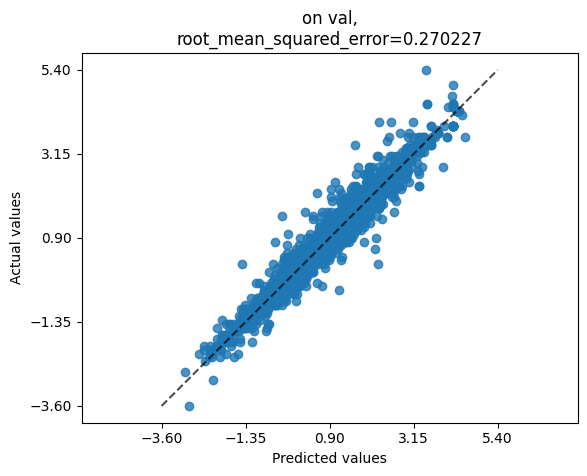

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.2695948912174499, 'score_CI': [0.2543271372816214, 0.2867268006298142]}


In [35]:
model="torch_models.FastPLMLPRegressor"

model_kwargs={
    "activation": "relu",
    "batch_size": 32,
    "dropout_rate": 0.0,
    "use_batchnorm": False,
    "epochs": 1000,
    "hidden_layer_sizes": [1024, 1024],
    "learning_rate": 0.0002,
    "weight_decay": 2e-5,
}

print(model_kwargs)
fitted_model = train_and_eval(model, model_kwargs, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.0, 'use_batchnorm': True, 'epochs': 1000, 'hidden_layer_sizes': [1024, 1024], 'learning_rate': 0.0002, 'weight_decay': 2e-05}


/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


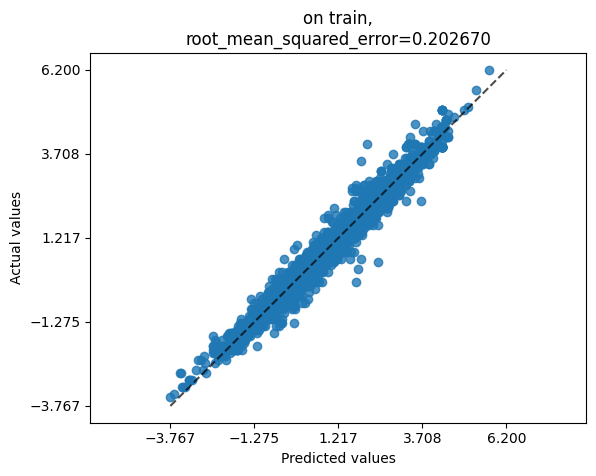

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.2027420501312642, 'score_CI': [0.19657672798139594, 0.2089026828497932]}


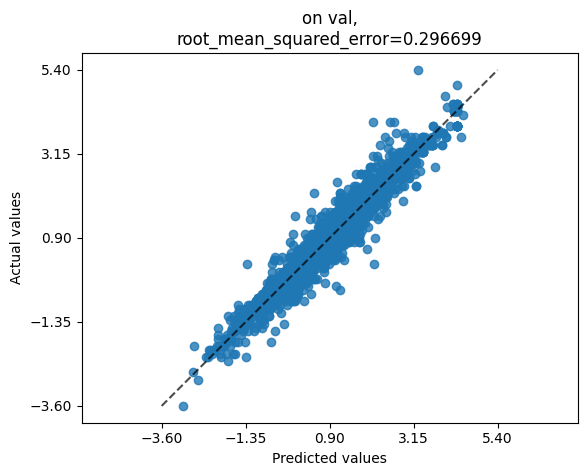

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.2961565566818665, 'score_CI': [0.2815529294800439, 0.3108596311325284]}


In [36]:
model="torch_models.FastPLMLPRegressor"

model_kwargs={
    "activation": "relu",
    "batch_size": 32,
    "dropout_rate": 0.0,
    "use_batchnorm": True,
    "epochs": 1000,
    "hidden_layer_sizes": [1024, 1024],
    "learning_rate": 0.0002,
    "weight_decay": 2e-5,
}

print(model_kwargs)
fitted_model = train_and_eval(model, model_kwargs, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.25, 'use_batchnorm': False, 'epochs': 1000, 'hidden_layer_sizes': [1024, 1024], 'learning_rate': 0.0002, 'weight_decay': 2e-05}


/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


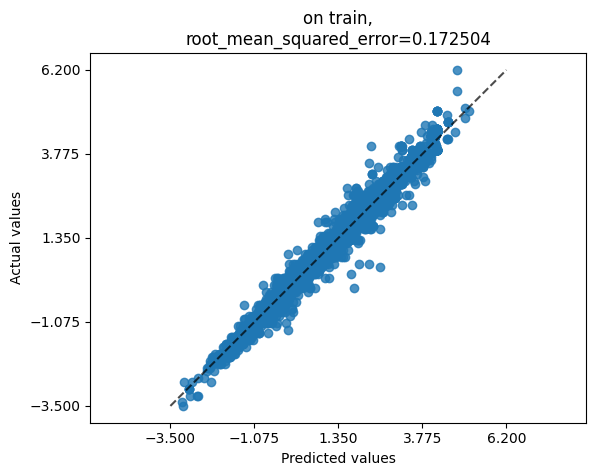

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.17257628657218038, 'score_CI': [0.16569162093191256, 0.17971787436080178]}


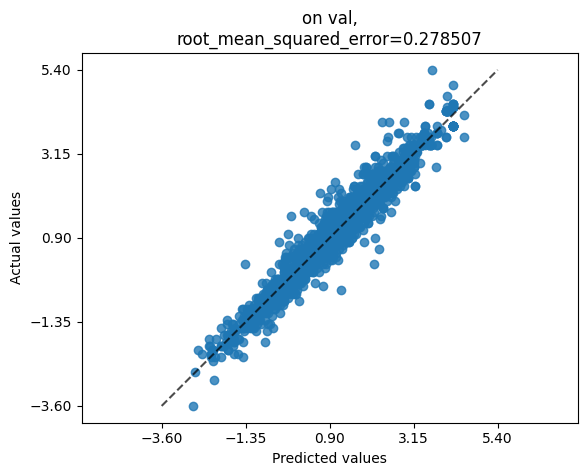

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.277860651490728, 'score_CI': [0.2635361356465085, 0.29352354468513214]}


In [37]:
model="torch_models.FastPLMLPRegressor"

model_kwargs={
    "activation": "relu",
    "batch_size": 32,
    "dropout_rate": 0.25,
    "use_batchnorm": False,
    "epochs": 1000,
    "hidden_layer_sizes": [1024, 1024],
    "learning_rate": 0.0002,
    "weight_decay": 2e-5,
}

print(model_kwargs)
fitted_model = train_and_eval(model, model_kwargs, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.25, 'use_batchnorm': True, 'epochs': 1000, 'hidden_layer_sizes': [1024, 1024], 'learning_rate': 0.0002, 'weight_decay': 2e-05}


/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/palko-wsl-ubuntu/projects/kaggle-chemical-structure-and-logp/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


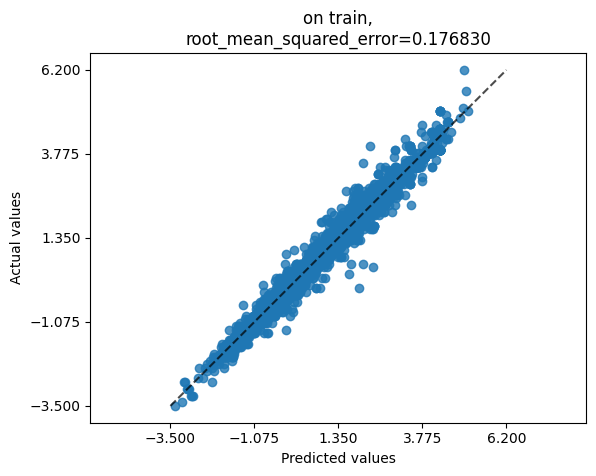

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.17690828587514618, 'score_CI': [0.16991113217810072, 0.18367175332050378]}


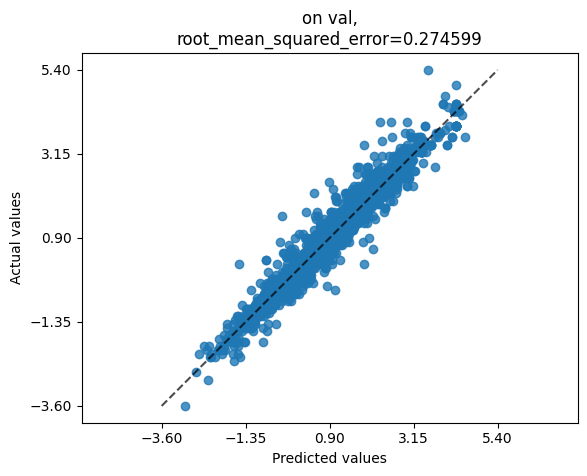

{'metric_name': 'root_mean_squared_error', 'score_mean': 0.2739497507237185, 'score_CI': [0.25909792113657065, 0.2892721343249515]}


In [38]:
model="torch_models.FastPLMLPRegressor"

model_kwargs={
    "activation": "relu",
    "batch_size": 32,
    "dropout_rate": 0.25,
    "use_batchnorm": True,
    "epochs": 1000,
    "hidden_layer_sizes": [1024, 1024],
    "learning_rate": 0.0002,
    "weight_decay": 2e-5,
}

print(model_kwargs)
fitted_model = train_and_eval(model, model_kwargs, data)